<a href="https://colab.research.google.com/github/amanusmani3sep-bit/House_prediction/blob/main/house_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv("/content/train.csv")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


In [ ]:
df.shape


(1460, 81)

In [ ]:
df.columns


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [ ]:
df.sample(5)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1196,1197,60,RL,58.0,14054,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,7,5,2006,2006,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,Gd,TA,PConc,Gd,TA,Av,Unf,0,Unf,0,879,879,GasA,Ex,Y,SBrkr,879,984,0,1863,0,0,2,1,4,1,Gd,9,Typ,1,Gd,BuiltIn,2006.0,Fin,3,660,TA,TA,Y,100,17,0,0,0,0,NaN,NaN,NaN,0,11,2006,New,Partial,219210
1358,1359,160,FV,NaN,2117,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,Twnhs,2Story,6,5,2000,2000,Gable,CompShg,MetalSd,MetalSd,BrkFace,216.0,Gd,TA,PConc,Gd,TA,No,GLQ,378,Unf,0,378,756,GasA,Ex,Y,SBrkr,769,804,0,1573,0,0,2,1,3,1,Gd,5,Typ,0,NaN,Detchd,2000.0,Unf,2,440,TA,TA,Y,0,32,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal,177500
979,980,20,RL,80.0,8816,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,Sawyer,Feedr,Norm,1Fam,1Story,5,6,1963,1963,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,TA,TA,No,Rec,651,Unf,0,470,1121,GasA,TA,Y,SBrkr,1121,0,0,1121,1,0,1,0,3,1,TA,5,Typ,0,NaN,Detchd,1963.0,Unf,2,480,TA,TA,Y,0,80,0,0,0,0,NaN,MnPrv,NaN,0,6,2009,WD,Normal,139000
472,473,180,RM,35.0,3675,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,TwnhsE,SLvl,6,5,2005,2005,Gable,CompShg,VinylSd,VinylSd,BrkFace,80.0,TA,TA,PConc,Gd,TA,Gd,GLQ,459,Unf,0,88,547,GasA,Ex,Y,SBrkr,1072,0,0,1072,1,0,1,0,2,1,TA,5,Typ,0,NaN,Basment,2005.0,RFn,2,525,TA,TA,Y,0,28,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,148000
525,526,20,FV,62.0,7500,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,7,5,2005,2005,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,Gd,TA,PConc,Gd,TA,No,Unf,0,Unf,0,1257,1257,GasA,Ex,Y,SBrkr,1266,0,0,1266,0,0,2,0,3,1,Gd,6,Typ,1,TA,Attchd,2005.0,Unf,2,453,TA,TA,Y,38,144,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Normal,176000


In [ ]:
df.info()


In [ ]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
Street,0
Alley,1369
LotShape,0
LandContour,0
Utilities,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
cat_cols=df.select_dtypes(include='object').columns
num_cols=df.select_dtypes(include='number').columns


In [ ]:
cat_cols=df[cat_cols]
num_cols=df[num_cols]


In [ ]:
print(cat_cols.shape)
print(num_cols.shape)
cat_cols.columns

(1460, 43)
(1460, 38)


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [ ]:
df["Condition1"].value_counts()

,count
Condition1,
Norm,1260
Feedr,81
Artery,48
RRAn,26
PosN,19
RRAe,11
PosA,8
RRNn,5
RRNe,2


In [ ]:
num_cols=df.select_dtypes(include='number').columns
cat_cols=df.select_dtypes(include='object').columns
num_cols=df[num_cols]
cat_cols=df[cat_cols]
print(num_cols.shape)
print(cat_cols.shape)

(1460, 38)
(1460, 43)


##EDA UNIVARIENT

In [ ]:
num_cols.sample(5)

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
1200,1201,20,71.0,9353,4,5,1970,1970,0.0,0,0,864,864,864,0,0,864,0,0,1,0,3,1,5,0,1972.0,1,280,0,0,0,0,0,0,0,7,2006,116050
830,831,20,80.0,11900,6,5,1957,1957,387.0,1040,0,352,1392,1392,0,0,1392,1,0,1,1,3,1,6,2,1957.0,2,458,0,0,0,0,192,0,0,6,2008,166000
233,234,20,75.0,10650,5,6,1976,1976,0.0,182,712,0,894,894,0,0,894,1,0,1,0,3,1,5,0,1976.0,1,308,365,0,0,0,0,0,0,2,2010,128200
1286,1287,20,NaN,9790,6,5,1963,1963,451.0,569,81,678,1328,1328,0,0,1328,1,0,1,1,3,1,6,2,1963.0,2,528,0,26,0,0,0,0,0,6,2010,143000
115,116,160,34.0,3230,6,5,1999,1999,1129.0,419,0,310,729,729,729,0,1458,0,0,2,1,2,1,5,1,1999.0,2,440,0,32,0,0,0,0,0,6,2007,176000


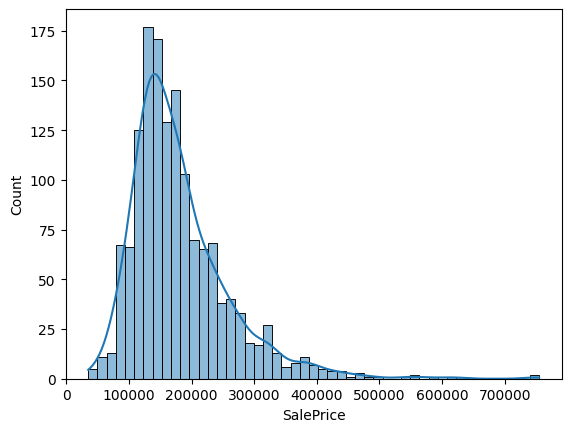

In [ ]:
sns.histplot(num_cols["SalePrice"],kde=True)
plt.show()

In [ ]:
num_cols["SalePrice"].skew()

np.float64(1.8828757597682129)

In [ ]:
# a=num_cols["MSSubClass"].value_counts().sort_index()
# plt.bar(a.index,a.values)
# plt.xlabel("MSSubClass")
# plt.ylabel("count")
# plt.show()

Text(0, 0.5, 'SalePrice')

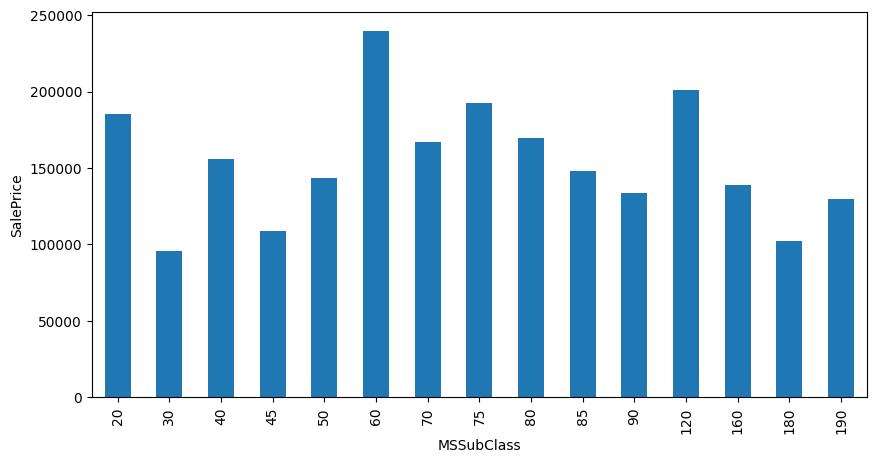

In [ ]:
plt.figure(figsize=(10,5))
num_cols.groupby("MSSubClass")["SalePrice"].mean().plot(kind="bar")
plt.xlabel("MSSubClass")
plt.ylabel("SalePrice")

In [ ]:
# sns.scatterplot(x=num_cols["LotFrontage"],y=num_cols["SalePrice"],hue=df["Neighborhood"])
# plt.show()
# g = sns.FacetGrid(
#     df,
#     col="Neighborhood",
#     col_wrap=4,
#     height=3
# )

# g.map_dataframe(
#     sns.scatterplot,
#     x="LotFrontage",
#     y="SalePrice"
# )
sns.relplot(data=df,x="LotFrontage",y="SalePrice",col="Neighborhood", col_wrap=4,height=3)

plt.show()

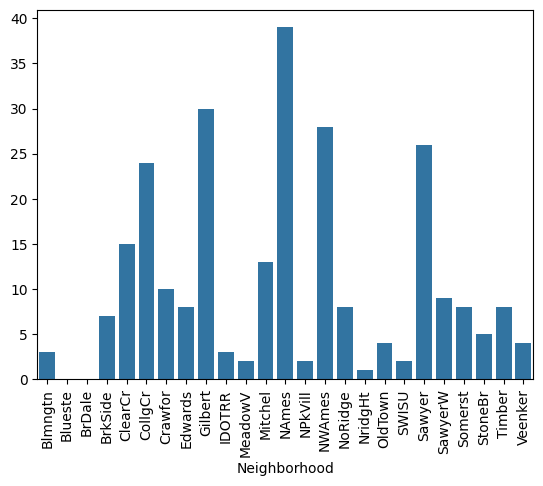

In [ ]:
#LotFrontage-->having 259 null values
k=df["Neighborhood"].value_counts()-df.groupby("Neighborhood")["LotFrontage"].count()
# plt.bar(k.index,k.values)
sns.barplot(x=k.index,y=k.values)
plt.xticks(rotation=90)
plt.show()
#here we get

In [ ]:
df.groupby("Neighborhood")["LotFrontage"].agg(["mean","median","count","size","skew","min","max"])

,mean,median,count,size,skew,min,max
Neighborhood,,,,,,,
Blmngtn,47.142857,43.0,14,17,0.356222,43.0,53.0
Blueste,24.000000,24.0,2,2,NaN,24.0,24.0
BrDale,21.562500,21.0,16,16,1.771925,21.0,24.0
BrkSide,57.509804,52.0,51,58,4.154470,50.0,144.0
ClearCr,83.461538,80.0,13,28,2.155355,62.0,138.0
CollgCr,71.682540,70.0,126,150,0.826432,36.0,122.0
Crawfor,71.804878,74.0,41,51,0.697890,40.0,130.0
Edwards,68.217391,65.5,92,100,4.942113,24.0,313.0
Gilbert,79.877551,65.0,49,79,1.660707,42.0,182.0


"LotFrontage shows substantial variation across Neighborhoods, and several Neighborhoods exhibit positive skewness. Therefore, Neighborhood-wise median imputation is chosen because the median is robust to extreme values and preserves the local distribution of LotFrontage better than a single global value."

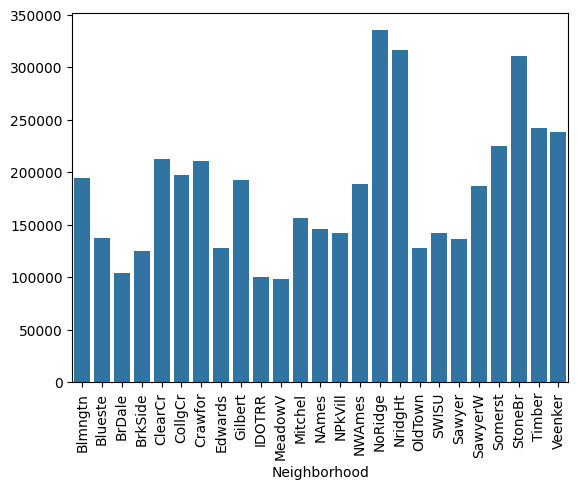

In [ ]:
sns.barplot(x=df.groupby('Neighborhood')["SalePrice"].mean().index,y=df.groupby('Neighborhood')["SalePrice"].mean().values)
plt.xticks(rotation=90)
plt.show()
#

In [ ]:
num_cols["LotFrontage"]=num_cols["LotFrontage"].fillna(df.groupby("Neighborhood")["LotFrontage"].transform("median"))
num_cols["LotFrontage"]

In [ ]:
df.groupby("Neighborhood")["LotArea"].agg(["count","size","min","max","mean"])


,count,size,min,max,mean
Neighborhood,,,,,
Blmngtn,17,17,3010,4045,3398.176471
Blueste,2,2,1300,1950,1625.000000
BrDale,16,16,1680,2368,1801.000000
BrkSide,58,58,4130,21384,7360.413793
ClearCr,28,28,2887,159000,30875.750000
CollgCr,150,150,4426,16285,9619.146667
Crawfor,51,51,3842,32668,11809.686275
Edwards,100,100,2522,63887,10218.650000
Gilbert,79,79,7415,34650,11379.151899


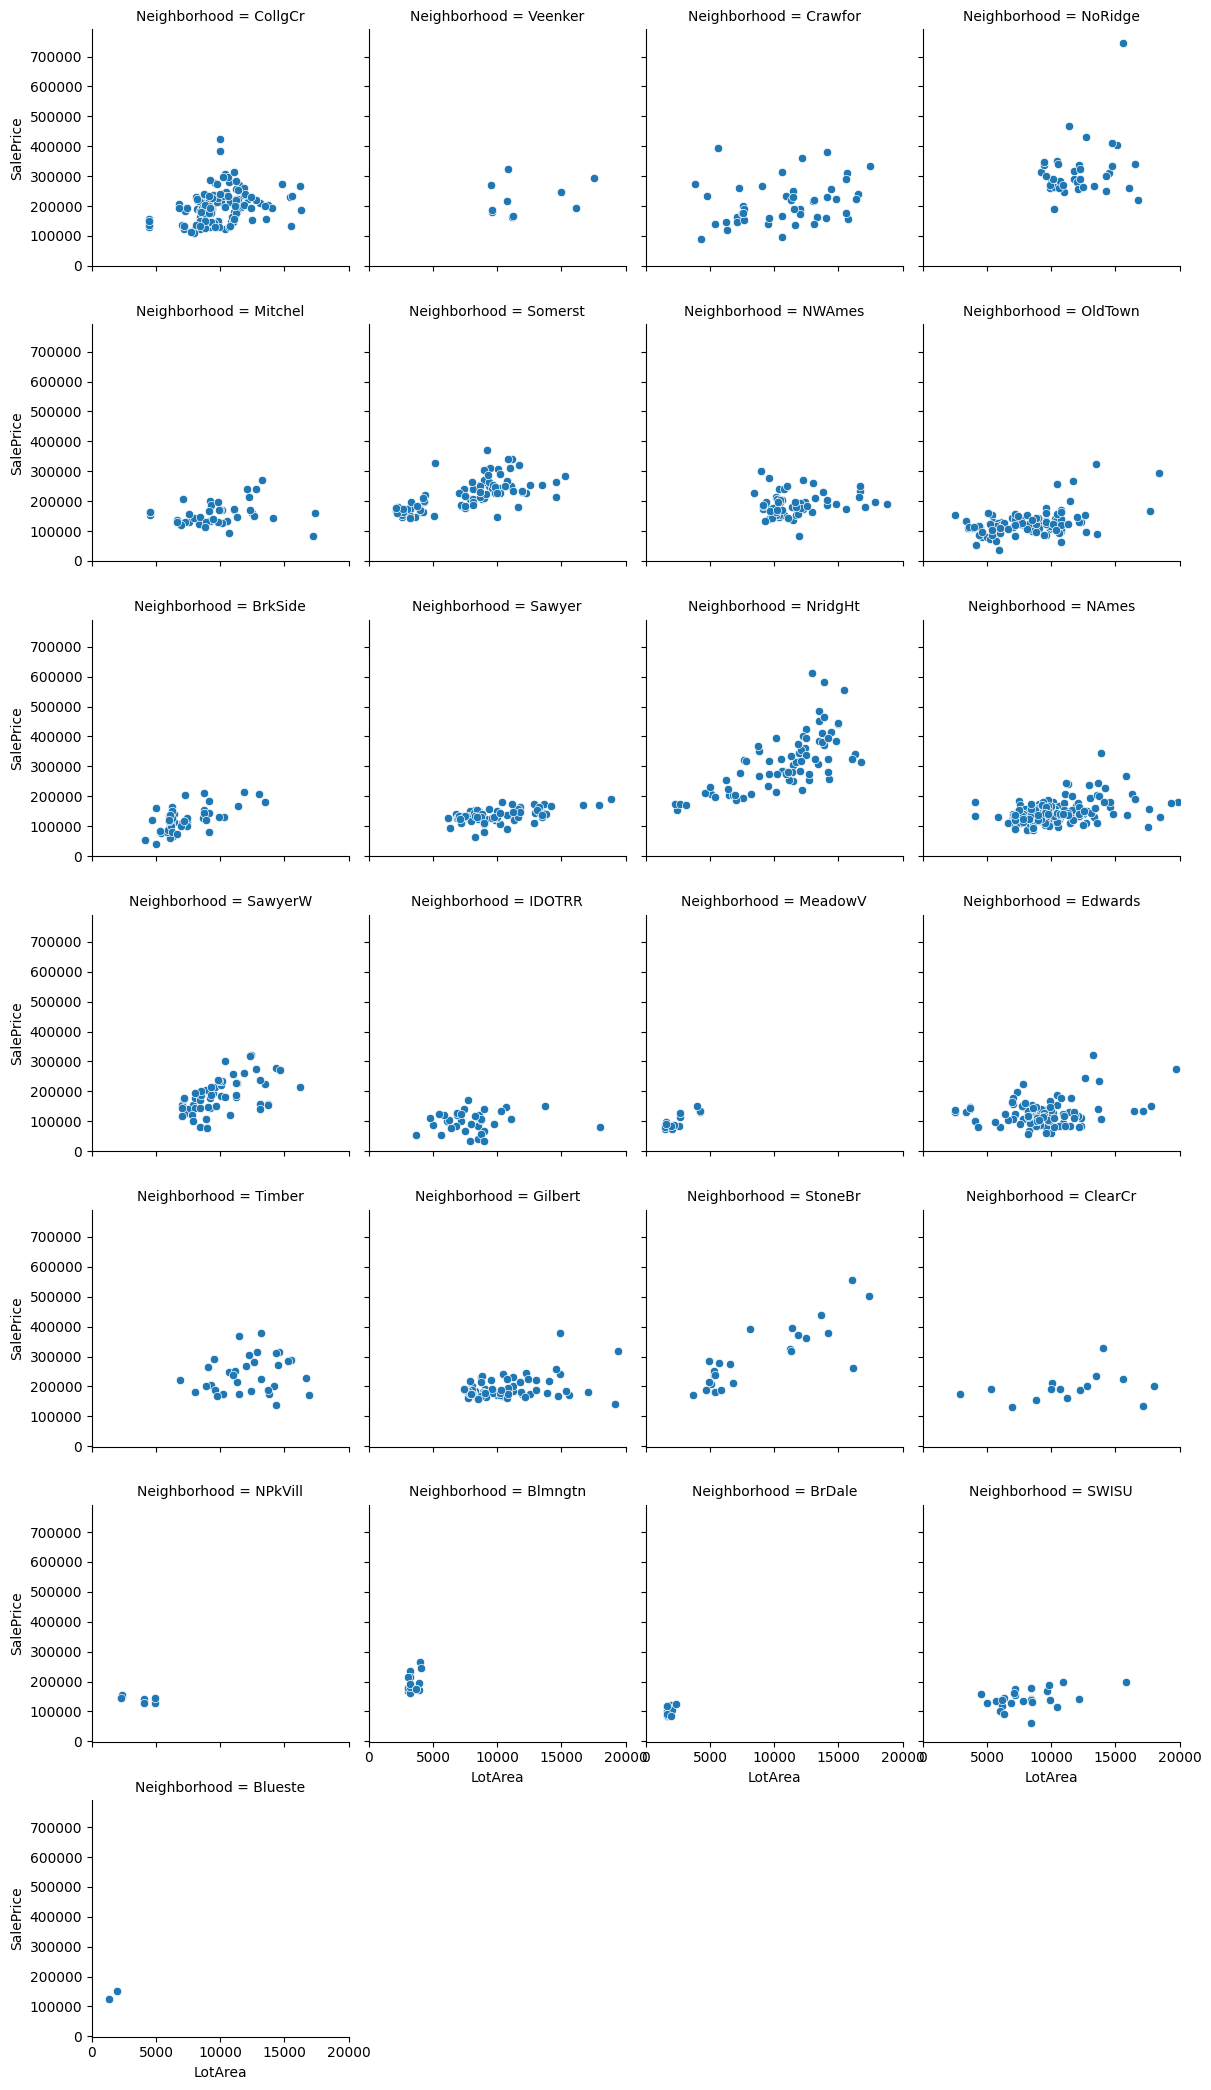

In [ ]:
#LotArea
g=sns.FacetGrid(
    data=df,
    col="Neighborhood",
    col_wrap=4,
    height=3
)
g.map_dataframe(
    sns.scatterplot,
    x="LotArea",
    y="SalePrice"
)
g.set(xlim=(0, 20000))
plt.show()

In [ ]:
#overallquality
num_cols["OverallQual"].value_counts().sort_index()

,count
OverallQual,
1,2
2,3
3,20
4,116
5,397
6,374
7,319
8,168
9,43


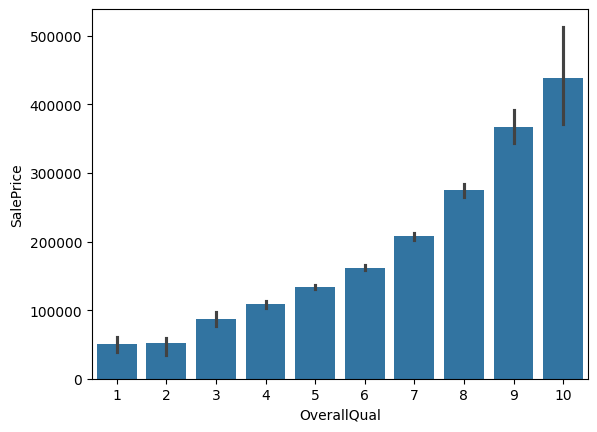

In [ ]:
sns.barplot(x=num_cols["OverallQual"],y=num_cols["SalePrice"])
plt.show()

##we can see that overall quality is directly poroptional to sale-prices

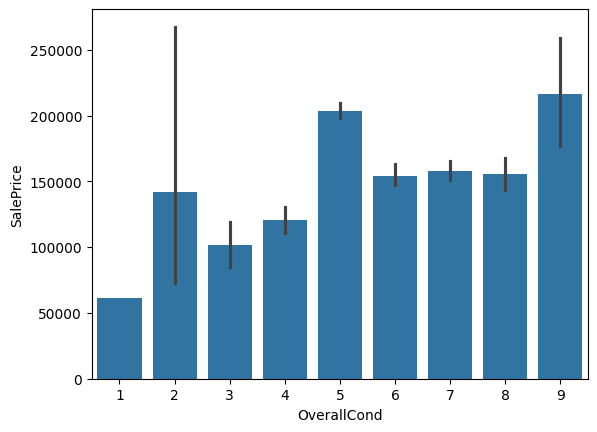

In [ ]:
sns.barplot(x=num_cols["OverallCond"],y=num_cols["SalePrice"])
plt.show()

In [ ]:
num_cols.corr()["SalePrice"].sort_values(ascending=False)


,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


In [ ]:
#  num_cols["GarageCars"].corr(num_cols["GarageArea"])
sns.lineplot(x=num_cols["GarageCars"],y=num_cols["SalePrice"])



In [ ]:
sns.lineplot(x=num_cols["GarageArea"],y=num_cols["SalePrice"])

As we can see that GarageCars giving us more strong relation with saleprice then GarageArea

In [ ]:
# sns.scatterplot(x=num_cols["GrLivArea"],y=num_cols["SalePrice"])
# plt.xlim(0,4500)
g=sns.FacetGrid(
    data=df,
    col="Neighborhood",
    col_wrap=3,
    height=3

)
g.map_dataframe(
    sns.scatterplot,
    x="GrLivArea",
    y="SalePrice"
)

In [ ]:
# sns.scatterplot(x=num_cols["TotalBsmtSF"],y=num_cols["1stFlrSF"])
# plt.xlim(0,3500)
num_cols["TotalBsmtSF"].min()
# num_cols.corr()["TotalBsmtSF"].sort_values(ascending=False)

0

In [ ]:
#id is not important so will drop it

#feature selection

The numerical Features we are going to selects are
OverallQual
GrLivArea
GarageCars
TotalBsmtSF
1stFlrSF
FullBath
TotRmsAbvGrd
YearBuilt

The categorical Features we are going to selects are

In [ ]:
slected_col=df[["OverallQual",	"GrLivArea",	"GarageCars","TotalBsmtSF",	"1stFlrSF","FullBath",	"TotRmsAbvGrd",	"YearBuilt",
                ]]

In [ ]:
sd,jabnojdk